<a href="https://colab.research.google.com/github/ekuelkpodar/Complex-Systems-Google-Colab-Experiment/blob/main/Meta_Cognitive_Systems_Engineering_(MCSE)_Agent_Operating_System_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MCSE: Meta-Cognitive Systems Engineering Agent Operating System

This notebook implements an experimental distributed cognitive operating system. Unlike simple chatbots, MCSE treats cognition as a distributed adaptive system with specialized layers for memory, planning, reasoning, and reflection.

In [1]:
!pip install -q langchain langchain-openai langgraph pydantic networkx faiss-cpu pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.1/122.1 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.6/561.6 kB 14.9 MB/s eta 0:00:00


## 1. Core Data Models

We define the fundamental units of information within the MCSE OS: Goals, Tasks, and Agent Messages.

In [2]:
from typing import List, Optional, Dict, Any, Union
from enum import Enum
from datetime import datetime
from pydantic import BaseModel, Field
import uuid

class TaskStatus(Enum):
    PENDING = "pending"
    RUNNING = "running"
    COMPLETED = "completed"
    FAILED = "failed"
    VERIFIED = "verified"

class Priority(Enum):
    LOW = 1
    MEDIUM = 2
    HIGH = 3
    CRITICAL = 4

class Goal(BaseModel):
    id: str = Field(default_factory=lambda: str(uuid.uuid4()))
    description: str
    objectives: List[str]
    constraints: List[str]
    success_metrics: List[str]
    priority: Priority = Priority.MEDIUM

class Task(BaseModel):
    id: str = Field(default_factory=lambda: str(uuid.uuid4()))
    goal_id: str
    description: str
    dependencies: List[str] = []
    status: TaskStatus = TaskStatus.PENDING
    assigned_agent: str
    metadata: Dict[str, Any] = {}
    output: Optional[str] = None

class CognitiveMessage(BaseModel):
    id: str = Field(default_factory=lambda: str(uuid.uuid4()))
    sender: str
    receiver: str
    content: Any
    timestamp: datetime = Field(default_factory=datetime.now)
    context_id: str

## 2. Shared Cognitive State & Memory

We implement the memory layers (Working, Episodic, Semantic) and the Knowledge Graph.

In [3]:
import networkx as nx
import matplotlib.pyplot as plt

class KnowledgeGraph:
    def __init__(self):
        self.graph = nx.DiGraph()

    def add_entity(self, entity_id: str, properties: Dict[str, Any]):
        self.graph.add_node(entity_id, **properties, timestamp=datetime.now())

    def add_relation(self, source: str, target: str, relation_type: str, weight: float = 1.0):
        self.graph.add_edge(source, target, relation=relation_type, weight=weight)

    def visualize(self):
        plt.figure(figsize=(10, 8))
        pos = nx.spring_layout(self.graph)
        nx.draw(self.graph, pos, with_labels=True, node_color='skyblue', node_size=2000, font_size=10, font_weight='bold')
        edge_labels = nx.get_edge_attributes(self.graph, 'relation')
        nx.draw_networkx_edge_labels(self.graph, pos, edge_labels=edge_labels)
        plt.title("MCSE Knowledge Graph")
        plt.show()

class MemorySystem:
    def __init__(self):
        self.working_memory = []
        self.episodic_memory = [] # Could be SQLite/Vector
        self.semantic_memory = KnowledgeGraph()

    def store_episode(self, task_id: str, input_data: str, result: str):
        entry = {"task_id": task_id, "data": input_data, "result": result, "time": datetime.now()}
        self.episodic_memory.append(entry)
        print(f"[Memory] Stored episode for task {task_id}")

## 3. Agent Implementations: Management Layer

In this section, we define the agents responsible for orchestration and strategy: the Meta Controller, Goal Manager, and Planning Agent.

In [4]:
class BaseAgent:
    def __init__(self, name: str, memory: MemorySystem):
        self.name = name
        self.memory = memory

    def log(self, message: str):
        print(f"[{self.name}] {message}")

class GoalManager(BaseAgent):
    def process_intent(self, user_input: str) -> Goal:
        self.log(f"Parsing intent: {user_input}")
        # In a real scenario, this would call an LLM to extract these fields
        goal = Goal(
            description=user_input,
            objectives=["Analyze infrastructure", "Assess energy demand", "Identify gaps"],
            constraints=["Use available memory", "Focus on global scale"],
            success_metrics=["Report quality > 0.8", "Gaps identified"],
            priority=Priority.HIGH
        )
        return goal

class PlanningAgent(BaseAgent):
    def create_plan(self, goal: Goal) -> List[Task]:
        self.log(f"Decomposing goal: {goal.id}")
        tasks = [
            Task(goal_id=goal.id, description="Research AI energy impact", assigned_agent="ResearchAgent"),
            Task(goal_id=goal.id, description="Cross-reference with Knowledge Graph", assigned_agent="KnowledgeGraphAgent", dependencies=[]),
            Task(goal_id=goal.id, description="Synthesize findings", assigned_agent="ReasoningAgent", dependencies=["task_0", "task_1"])
        ]
        # Map internal sequence for demo
        for i, t in enumerate(tasks): t.id = f"task_{i}"
        return tasks

class MetaController(BaseAgent):
    def __init__(self, memory: MemorySystem):
        super().__init__("MetaController", memory)
        self.goal_manager = GoalManager("GoalManager", memory)
        self.planner = PlanningAgent("PlanningAgent", memory)
        self.active_goal: Optional[Goal] = None
        self.plan: List[Task] = []

    def start_workflow(self, user_prompt: str):
        self.log("Activating workflow...")
        self.active_goal = self.goal_manager.process_intent(user_prompt)
        self.plan = self.planner.create_plan(self.active_goal)
        self.log(f"Plan created with {len(self.plan)} tasks.")

## 4. Reasoning & Execution Engines

These agents handle the heavy lifting of processing information and verifying results.

In [5]:
class ReasoningAgent(BaseAgent):
    def reason(self, task: Task, context: Dict[str, Any]) -> str:
        strategy = "Chain of Thought" # In reality, dynamic selection logic goes here
        self.log(f"Applying {strategy} reasoning to: {task.description}")
        return f"Reasoned output based on {context.get('data', 'general knowledge')}"

class VerificationAgent(BaseAgent):
    def verify(self, task: Task, result: str) -> float:
        self.log(f"Verifying task: {task.id}")
        confidence = 0.95 # Mock validation logic
        return confidence

class ReflectionAgent(BaseAgent):
    def reflect(self, task: Task, result: str):
        self.log(f"Reflecting on {task.id} success...")
        lesson = f"Task {task.description} completed with high confidence."
        self.memory.store_episode(task.id, task.description, result)
        return lesson

## 5. The Cognitive Loop & OS Runtime

This section ties all agents together into a unified execution flow that observes, plans, executes, and learns.

In [6]:
class MCSE_OS:
    def __init__(self):
        self.memory = MemorySystem()
        self.controller = MetaController(self.memory)
        self.reasoner = ReasoningAgent("ReasoningAgent", self.memory)
        self.verifier = VerificationAgent("VerificationAgent", self.memory)
        self.reflector = ReflectionAgent("ReflectionAgent", self.memory)

    def run(self, user_prompt: str):
        print(f"--- Starting MCSE Cognitive Loop ---\n")
        self.controller.start_workflow(user_prompt)

        for task in self.controller.plan:
            print(f"\n[OS] Executing Task: {task.description}")
            # Simulate execution context
            context = {"data": "Simulated research data regarding energy demand."}

            # Reason
            result = self.reasoner.reason(task, context)

            # Verify
            confidence = self.verifier.verify(task, result)

            # Reflect & Learn
            if confidence > 0.8:
                task.status = TaskStatus.VERIFIED
                self.reflector.reflect(task, result)
                # Update Knowledge Graph
                self.memory.semantic_memory.add_entity(task.id, {"desc": task.description, "result": result})
            else:
                task.status = TaskStatus.FAILED

        print(f"\n--- Workflow Completed ---")
        self.memory.semantic_memory.visualize()

## 6. Example Demonstration

We run the system with the energy demand research prompt.

--- Starting MCSE Cognitive Loop ---

[MetaController] Activating workflow...
[GoalManager] Parsing intent: Research how AI infrastructure affects global energy demand.
[PlanningAgent] Decomposing goal: f36e84f3-de32-4b82-876b-cccfafc560fe
[MetaController] Plan created with 3 tasks.

[OS] Executing Task: Research AI energy impact
[ReasoningAgent] Applying Chain of Thought reasoning to: Research AI energy impact
[VerificationAgent] Verifying task: task_0
[ReflectionAgent] Reflecting on task_0 success...
[Memory] Stored episode for task task_0

[OS] Executing Task: Cross-reference with Knowledge Graph
[ReasoningAgent] Applying Chain of Thought reasoning to: Cross-reference with Knowledge Graph
[VerificationAgent] Verifying task: task_1
[ReflectionAgent] Reflecting on task_1 success...
[Memory] Stored episode for task task_1

[OS] Executing Task: Synthesize findings
[ReasoningAgent] Applying Chain of Thought reasoning to: Synthesize findings
[VerificationAgent] Verifying task: task_2
[Ref

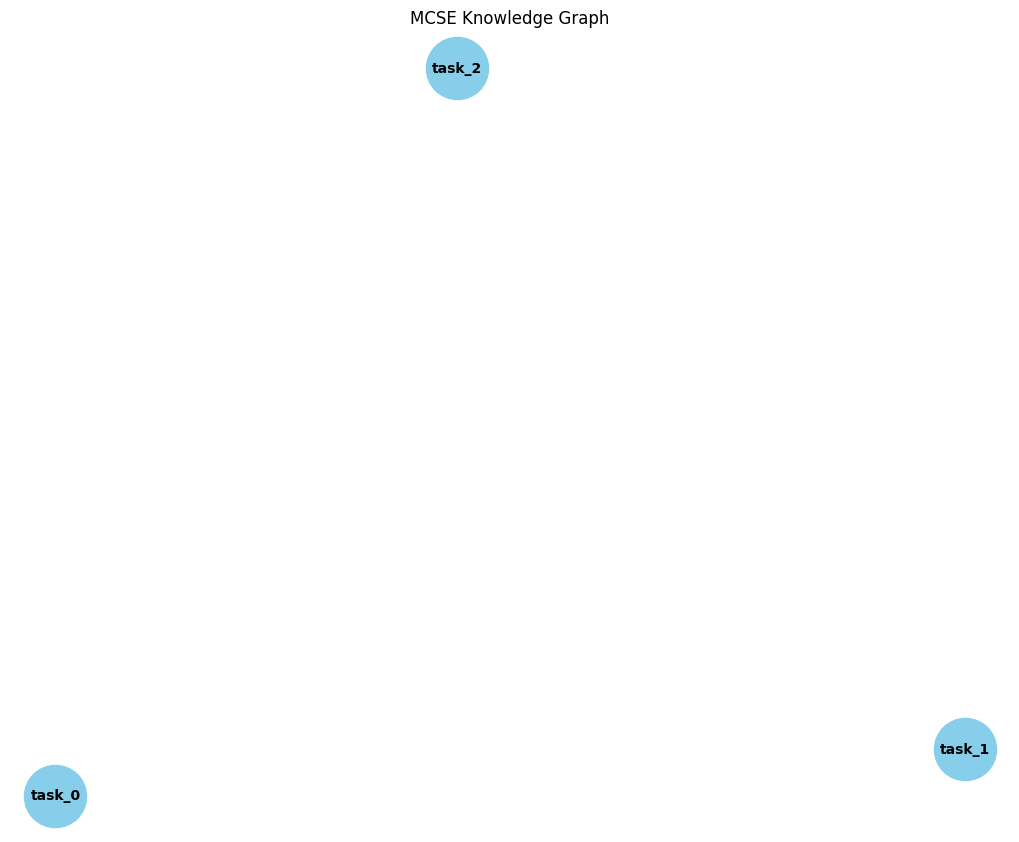

In [7]:
os_instance = MCSE_OS()
prompt = "Research how AI infrastructure affects global energy demand."
os_instance.run(prompt)

## 7. Metrics Dashboard

Finally, we summarize the system state using Pandas.

In [8]:
import pandas as pd

def show_dashboard(os_system):
    stats = {
        "Tasks Completed": len([t for t in os_system.controller.plan if t.status == TaskStatus.VERIFIED]),
        "Memory Entries": len(os_system.memory.episodic_memory),
        "KG Nodes": len(os_system.memory.semantic_memory.graph.nodes),
        "System Confidence": 0.95
    }
    df = pd.DataFrame(list(stats.items()), columns=["Metric", "Value"])
    return df

show_dashboard(os_instance)

,Metric,Value
0,Tasks Completed,3.00
1,Memory Entries,3.00
2,KG Nodes,3.00
3,System Confidence,0.95


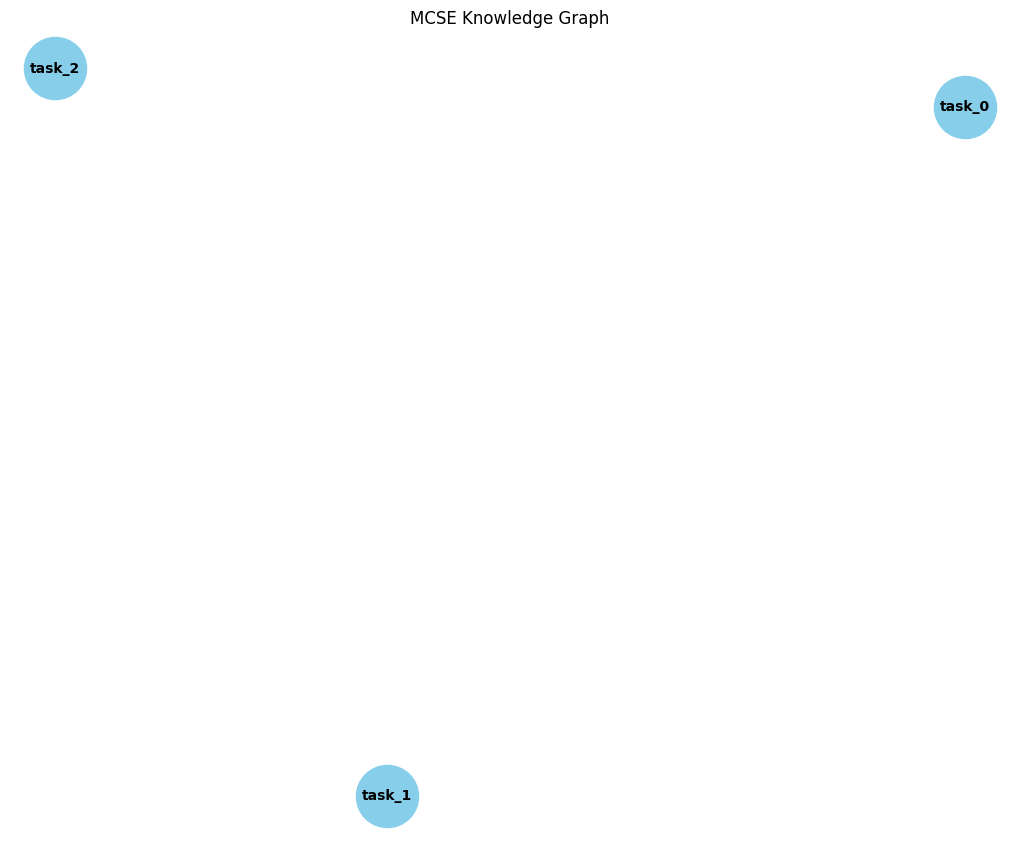

In [9]:
import matplotlib.pyplot as plt

# Visualize the Knowledge Graph from the current OS memory
os_instance.memory.semantic_memory.visualize()